# 01 - LV Scar Exploration

Focus: Core Zone (CZ) only.

Pipeline:
1. Scan + EDA
2. 80/20 split
3. 3-D visualisation (aligned overlay + grid)
4. 2-D polar maps + superposition
5. ISOMAP shape analysis

## 0 - Imports & config

In [1]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from data_loading import scan, diagnose, PatientCase

HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
TRAIN_RATIO      = 0.80
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_ISOMAP = 5

USE_PROXY        = False # True: CZ for those who have it + power_paths for the rest
                        # False: only real CZ cases

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120


## 1 - Scan & EDA

In [2]:
all_cases = scan(HD_ROOT)

def has_cz(c):
    p = c.tissue_surfaces.get("core")
    return p is not None and p.exists()

def has_proxy(c):
    p = c.tissue_surfaces.get("power_paths")
    return p is not None and p.exists()

def get_cz_mesh(c):
    """Return the CZ mesh for a case: real CZ if available, filled proxy otherwise."""
    if has_cz(c):
        return pv.read(str(c.tissue_surfaces["core"]))
    if USE_PROXY and has_proxy(c):
        pp = pv.read(str(c.tissue_surfaces["power_paths"]))
        return fill_power_paths(pp)
    return None

if USE_PROXY:
    valid = [c for c in all_cases if has_cz(c) or has_proxy(c)]
else:
    valid = [c for c in all_cases if has_cz(c)]

print(f"USE_PROXY        : {USE_PROXY}")
print(f"Total scanned    : {len(all_cases)}")
print(f"Real CZ          : {sum(1 for c in all_cases if has_cz(c))}")
print(f"Proxy only       : {sum(1 for c in all_cases if not has_cz(c) and has_proxy(c))}")
print(f"Valid (this run) : {len(valid)}")


USE_PROXY        : False
Total scanned    : 129
Real CZ          : 88
Proxy only       : 17
Valid (this run) : 88


### 1a - EDA: dataset overview

In [3]:
c1,c2,c3,c4,c5,c6 = "Year","Total","Has LV","Has CZ","Has Proxy","CZ+Proxy"
print(f"{c1:<6} {c2:>7} {c3:>8} {c4:>8} {c5:>11} {c6:>10}")
print("-" * 54)
for year in sorted(set(c.year for c in all_cases)):
    yc    = [c for c in all_cases if c.year == year]
    n_lv  = sum(1 for c in yc if c.lv_dir is not None)
    n_cz  = sum(1 for c in yc if has_cz(c))
    n_pp  = sum(1 for c in yc if not has_cz(c) and has_proxy(c))
    n_any = sum(1 for c in yc if has_cz(c) or has_proxy(c))
    print(f"{year:<6} {len(yc):>7} {n_lv:>8} {n_cz:>8} {n_pp:>11} {n_any:>10}")
print("-" * 54)
tot       = "TOTAL"
total_cz  = sum(1 for c in all_cases if has_cz(c))
total_pp  = sum(1 for c in all_cases if not has_cz(c) and has_proxy(c))
total_any = total_cz + total_pp
blank     = ""
print(f"{tot:<6} {len(all_cases):>7} {blank:>8} {total_cz:>8} {total_pp:>11} {total_any:>10}")


Year     Total   Has LV   Has CZ   Has Proxy   CZ+Proxy
------------------------------------------------------
2021        12       12       12           0         12
2022        27       23       11          11         22
2023        47       45       32           1         33
2024        31       31       31           0         31
2025        12        7        2           5          7
------------------------------------------------------
TOTAL      129                88          17        105


### 1b - Diagnostic: TISSUE contents for cases WITHOUT CZ

Run this to see what files are actually on disk.

In [4]:
no_cz = [c for c in all_cases if c.lv_dir is not None and c.tissue_surfaces.get("core") is None]
print(f"Cases with LV dir but no CZ matched: {len(no_cz)}")
for case in no_cz[:5]:
    diagnose(case)


Cases with LV dir but no CZ matched: 30

------------------------------------------------------------
Patient : 2022/02016806
LV dir  : F:\RM_TEKNON_DEVELOP\2022\02016806\Basal\Data\DE-MRI 3D\LV

  TISSUE/ contains 19 VTK files (recursive):
    3D Corridor 3D Border Zone.vtk
    3D Corridor Border Zone on Layer.vtk
    3D Corridor Centerlines.vtk
    3D Corridor Filtered Centerlines.vtk
    3D Corridor Labels.vtk
    3D Corridor Mask Image.vtk
    3D Corridor Unified Centerlines Tubes.vtk
    3D Corridor Unified Centerlines.vtk
    Automatic 3D Corridors.vtk
    Layer_10.vtk
    Layer_20.vtk
    Layer_30.vtk
    Layer_40.vtk
    Layer_50.vtk
    Layer_60.vtk
    Layer_70.vtk
    Layer_80.vtk
    Layer_90.vtk
    PowerPaths.vtk

  Resolved tissue_surfaces:
    core         -> NOT FOUND
    border_zone  -> 3D Corridor 3D Border Zone.vtk
    healthy      -> NOT FOUND
    scar         -> NOT FOUND
    power_paths  -> PowerPaths.vtk
----------------------------------------------------------

### 1c - Power Paths fill diagnostic

Power paths are line contours (Case A). This cell tests the fill
strategy on one sample case and renders the result.

Cases with power_paths: 101
Trying 2021/02026677
  n_points=889  n_cells=889
  22 loop(s) found
  Filled OK: n_faces_strict=1107


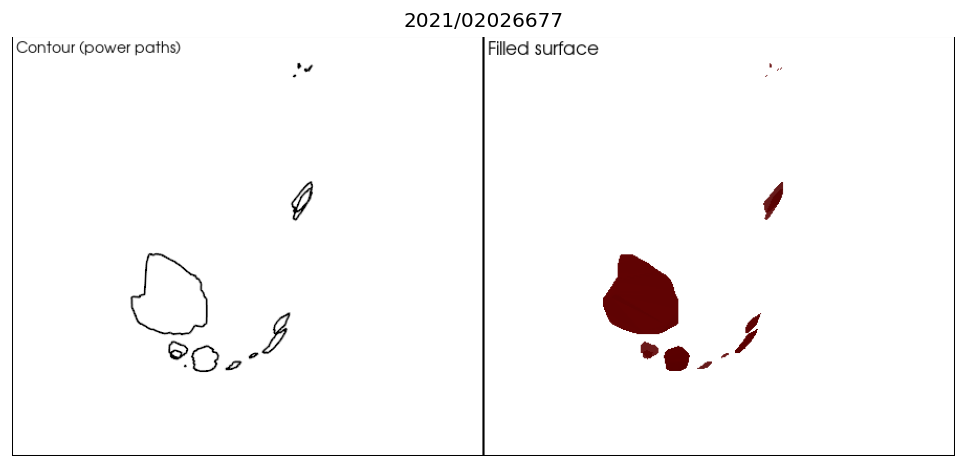

In [5]:
import pyvista as pv
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import connected_components

def fill_power_paths(pp_mesh, alpha_factor=0.8):
    """Fill line-contour power paths into a triangulated surface.

    alpha is set per loop as alpha_factor * bounding-box diagonal.
    Since loops have no interior points, alpha must span the full
    loop width - much larger than point spacing.
    alpha_factor < 1.0 keeps loops separate; > 1.0 may bridge gaps.
    """
    pts = np.array(pp_mesh.points)
    if len(pts) < 3:
        return None
    # Build adjacency from line cells
    n = len(pts)
    adj = lil_matrix((n, n), dtype=np.int8)
    cells = np.array(pp_mesh.lines)
    idx = 0
    while idx < len(cells):
        seg_len = int(cells[idx])
        if seg_len == 2:
            p0, p1 = int(cells[idx+1]), int(cells[idx+2])
            adj[p0, p1] = 1
            adj[p1, p0] = 1
        idx += seg_len + 1
    # Connected components = one per closed loop
    n_comp, labels = connected_components(adj.tocsr(), directed=False)
    print(f"  {n_comp} loop(s) found")
    # Fill each loop independently
    patches = []
    for cid in range(n_comp):
        loop_pts = pts[labels == cid]
        if len(loop_pts) < 3:
            continue
        # alpha = fraction of bounding-box diagonal (spans the interior)
        bbox_diag = float(np.linalg.norm(loop_pts.max(axis=0) - loop_pts.min(axis=0)))
        alpha = bbox_diag * alpha_factor
        try:
            patch = pv.PolyData(loop_pts).delaunay_2d(alpha=alpha)
            if patch.n_faces_strict > 0:
                patches.append(patch)
        except Exception as e:
            print(f"  loop {cid}: delaunay failed ({e})")
    if not patches:
        return None
    merged = patches[0]
    for p in patches[1:]:
        merged = merged.merge(p)
    return merged

pp_cases = [c for c in all_cases if c.tissue_surfaces.get("power_paths") is not None]
print(f"Cases with power_paths: {len(pp_cases)}")

test_case = pp_mesh = filled = None
for case in pp_cases[:5]:
    print(f"Trying {case.year}/{case.patient_id}")
    m = pv.read(str(case.tissue_surfaces["power_paths"]))
    print(f"  n_points={m.n_points}  n_cells={m.n_cells}")
    f = fill_power_paths(m)
    if f is not None:
        print(f"  Filled OK: n_faces_strict={f.n_faces_strict}")
        test_case, pp_mesh, filled = case, m, f
        break
    print("  Fill failed")

if filled is not None:
    pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(900, 400))
    pl.subplot(0, 0)
    pl.add_text("Contour (power paths)", font_size=8)
    pl.add_mesh(pp_mesh, color="black", line_width=2, render_lines_as_tubes=True)
    pl.set_background("white")
    pl.reset_camera()
    pl.subplot(0, 1)
    pl.add_text("Filled surface", font_size=8)
    pl.add_mesh(filled, color="red", opacity=0.9)
    pl.set_background("white")
    pl.reset_camera()
    img = pl.screenshot(None, return_img=True)
    pl.close()
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{test_case.year}/{test_case.patient_id}")
    plt.tight_layout()
    plt.show()
else:
    print("All 5 cases failed.")

## 2 - 80/20 split

In [6]:
random.seed(SEED)
shuffled = random.sample(valid, len(valid))
n_known  = int(len(shuffled) * TRAIN_RATIO)
known    = shuffled[:n_known]
held_out = shuffled[n_known:]

(RESULTS / "split.json").write_text(json.dumps({
    "seed": SEED, "train_ratio": TRAIN_RATIO,
    "known":    [f"{c.year}/{c.patient_id}" for c in known],
    "held_out": [f"{c.year}/{c.patient_id}" for c in held_out],
}, indent=2))
print(f"Known: {len(known)}   Held-out: {len(held_out)}")


Known: 70   Held-out: 18


## 3 - 3-D visualisation

Each render: Left Ventricle shell (semi-transparent) + CZ (opaque red).

For the overlay all LV meshes are aligned before stacking:
- apex translated to origin
- long axis rotated to Z (all hearts point the same way)

This makes the population view meaningful: you can see which LV regions tend to carry CZ scar.

In [7]:
def _best_shell(case):
    """Left Ventricle > Myocardium > Endo > Epi."""
    for key in ("lv", "myocardium", "endo", "epi"):
        p = case.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None


def _compute_transform(lv_mesh):
    """Returns (R, apex) so that (pts - apex) @ R.T puts apex at origin, long axis along +Z."""
    pts    = np.array(lv_mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    z  = np.array([0., 0., 1.])
    v  = np.cross(axis, z)
    s  = np.linalg.norm(v)
    c  = np.dot(axis, z)
    if s < 1e-9:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R  = np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))
    return R, apex


def _apply_transform(mesh, R, apex):
    m = mesh.copy()
    m.points = (np.array(mesh.points) - apex) @ R.T
    return m

print("3-D helpers ready.")


3-D helpers ready.


### 3b - Per-patient 3-D grid (first GRID3D_MAX cases)

3-D grid:   0%|          | 0/70 [00:00<?, ?it/s]

3-D grid: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 70/70 [00:24<00:00,  2.86it/s]


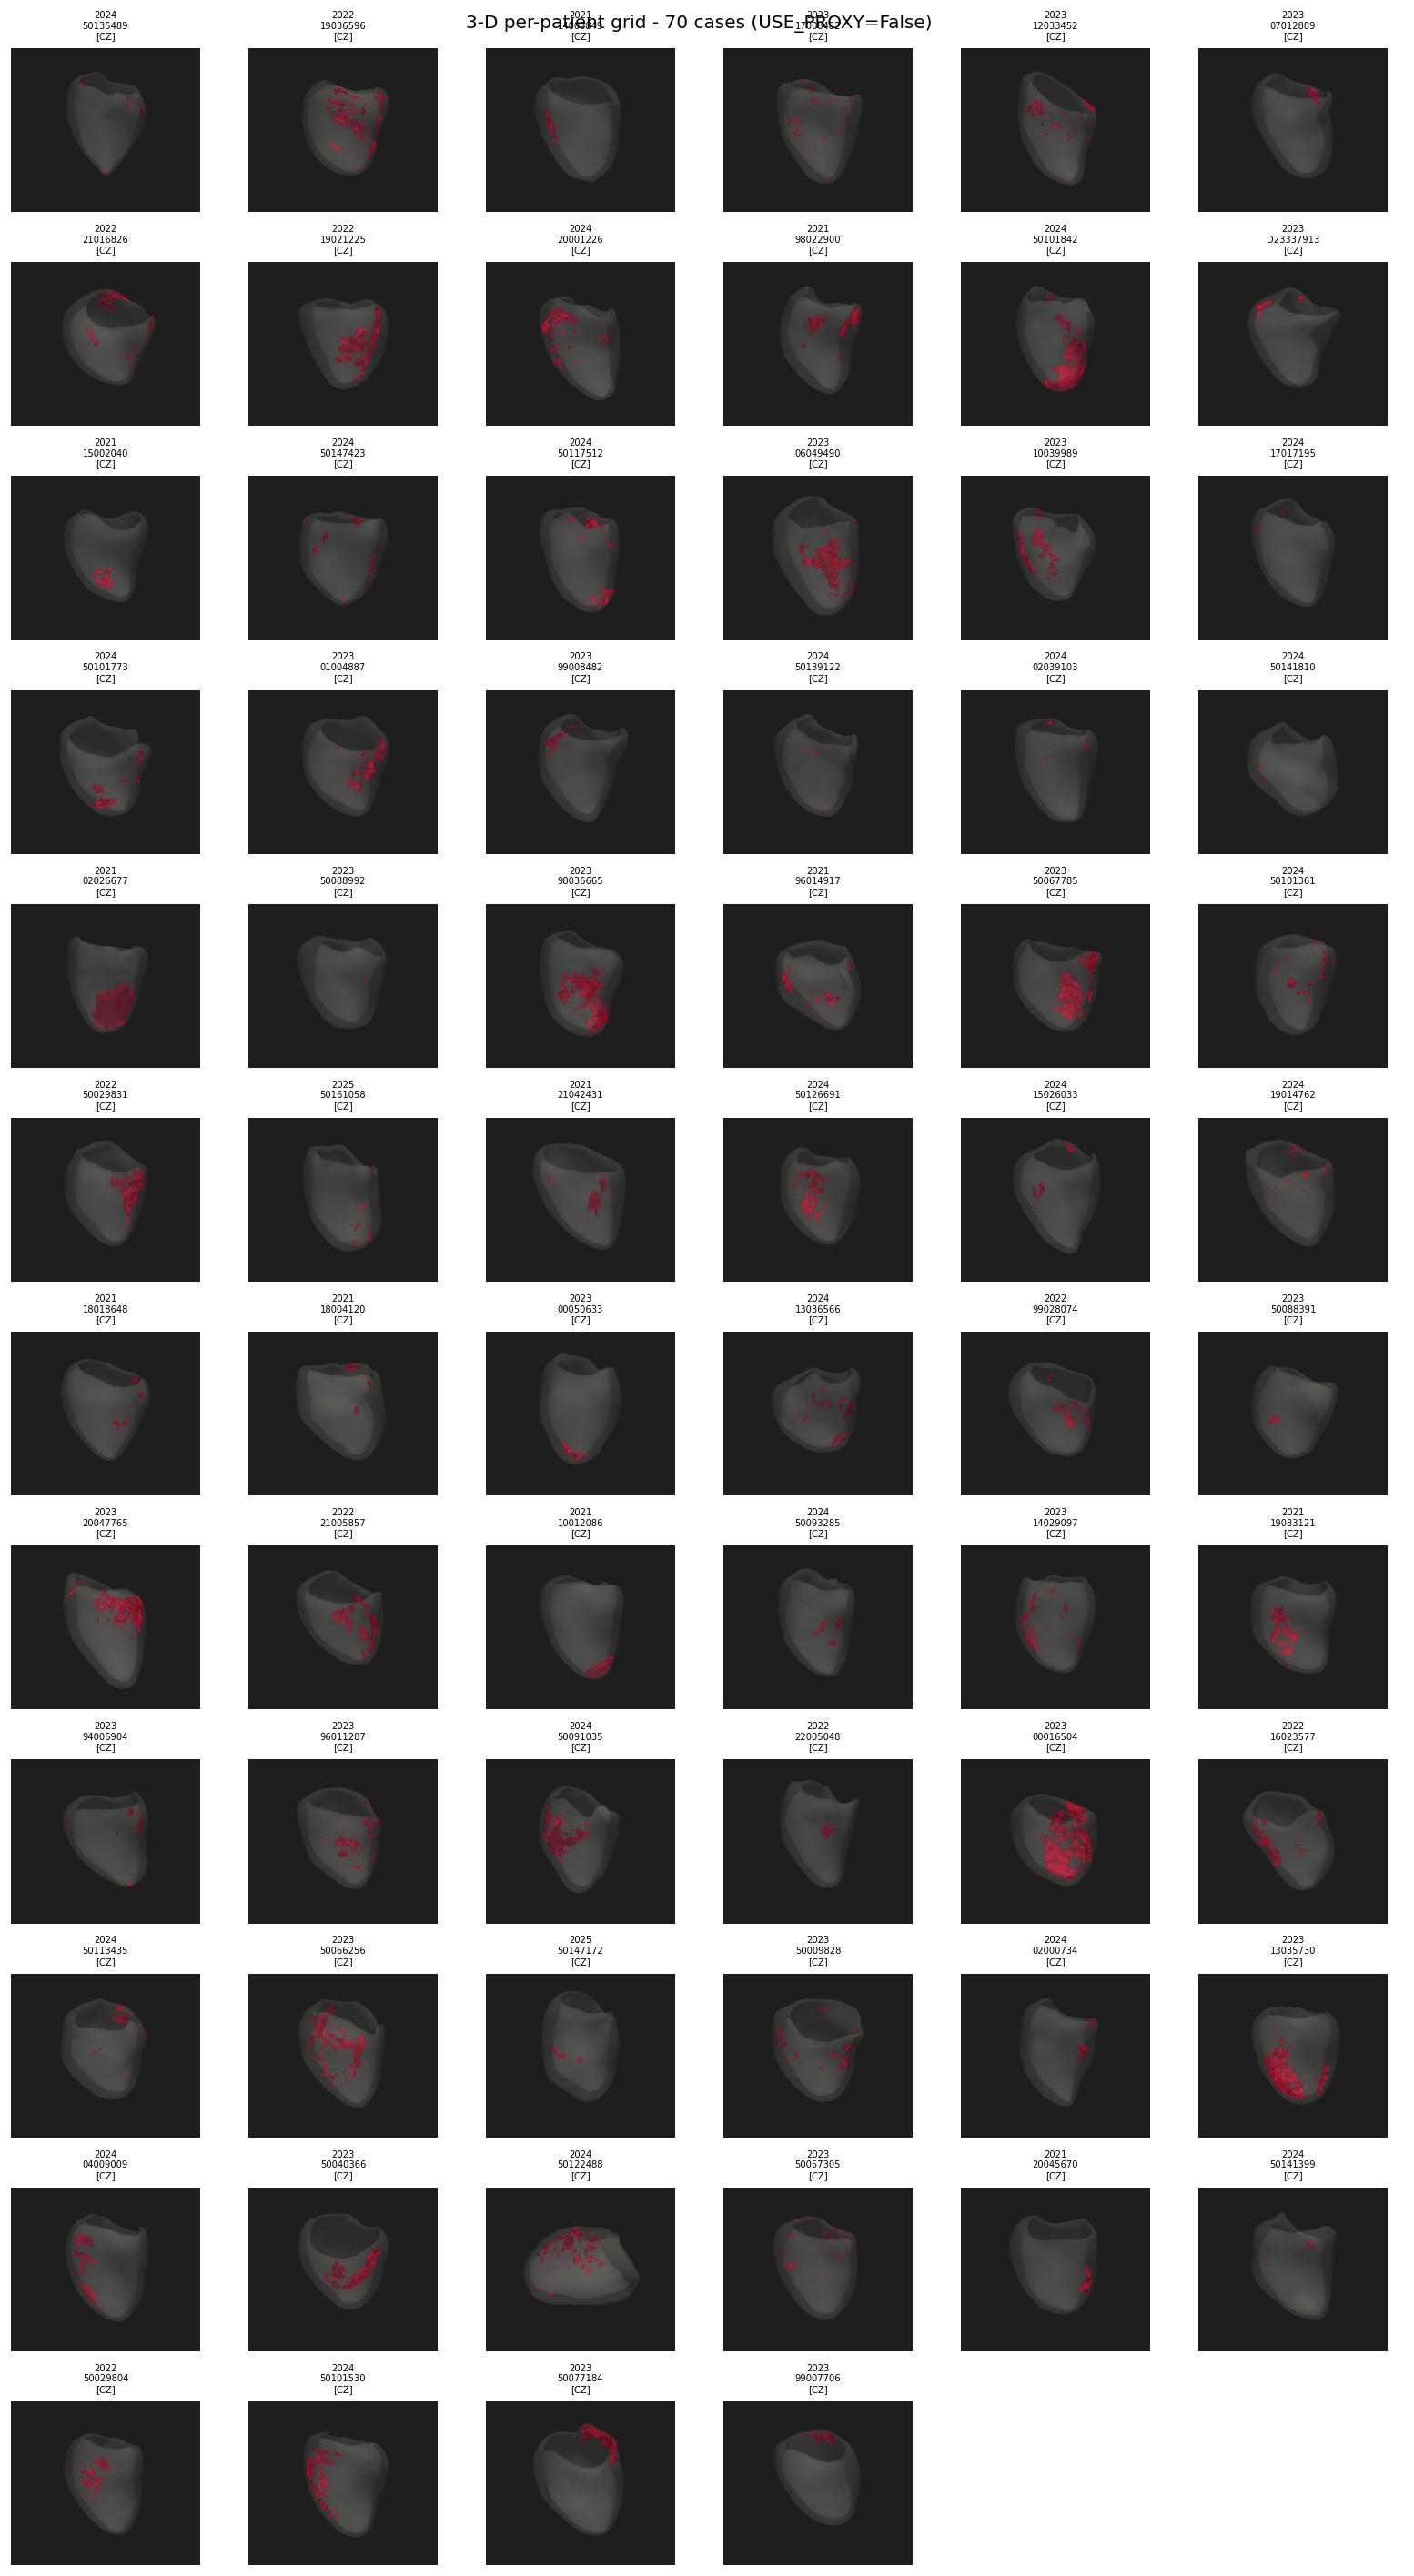

In [8]:
subset   = known
ncols_3d = 6
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc='3-D grid'):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background('#1e1e1e')
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='lightgray', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color='crimson', opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f'  skip {case.year}/{case.patient_id}: {e}')

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
fig.suptitle(f'3-D per-patient grid - {len(thumbnails)} cases (USE_PROXY={USE_PROXY})',
             fontsize=12)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis('off')
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    src = 'CZ' if has_cz(case) else 'proxy'
    ax.set_title(f'{case.year}\n{case.patient_id}\n[{src}]', fontsize=6)
plt.tight_layout()
plt.savefig(RESULTS / '3d_grid_known.png', bbox_inches='tight')
plt.show()


## 4 - 2-D cylindrical polar projection

How it works:
1. PCA on the LV shell finds the long axis (apex to base).
2. **RV insertion point** fixes theta=0: the LV cross-section at basal
   level has two concavities where the RV attaches (septal dents).
   The direction from the centroid toward their midpoint becomes the
   circumferential reference. Without this, theta=0 is arbitrary per
   patient and the superposition smears into a ring instead of hotspots.
3. Each CZ vertex gets r (0=apex, 1=base) and theta (0-360 from reference).
4. Rasterise onto an (N_R x N_THETA) binary grid.
5. Bull's-eye: apex at centre, base at outer ring.

Known limitation: apex is a dome so apical scars spread over the inner disc.
Use ISOMAP (Section 5) for faithful shape analysis.


In [ ]:
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec

def _long_axis(mesh):
    pts    = np.array(mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    return axis, apex


def _plane_basis(axis):
    sec = np.array([0., 0., 1.])
    if abs(np.dot(axis, sec)) > 0.9:
        sec = np.array([1., 0., 0.])
    u = np.cross(axis, sec); u /= np.linalg.norm(u)
    w = np.cross(axis, u)
    return u, w


def _rv_reference(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Method A - dip detection: direction toward midpoint of 2 deepest radial dips.

    The two deepest concavities in the basal ring correspond to the RV attachment
    points. Falls back to an arbitrary stable direction when fewer than 2 dips
    are found. Sensitive to manual segmentation artefacts that introduce extra dips.
    """
    u, w  = _plane_basis(axis)
    pts   = np.array(lv_mesh.points)
    proj  = (pts - apex) @ axis
    span  = proj.max() - proj.min()
    mask  = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring  = pts[mask]
    if len(ring) < 20:
        return u
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    if len(peaks) < 2:
        return u
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]]
    ins_ang  = np.arctan2(diff[idx[top2], 1], diff[idx[top2], 0])
    mid_2d   = np.array([np.cos(ins_ang).mean(), np.sin(ins_ang).mean()])
    norm     = np.linalg.norm(mid_2d)
    if norm < 1e-9:
        return u
    return (mid_2d[0] * u + mid_2d[1] * w) / norm


def _rv_reference_pca(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Method B - PCA on basal ring shape: direction toward the concave (septal) side.

    PC1 of the 2-D basal cross-section is the axis of maximum variance, which
    passes through the two RV insertion concavities. Disambiguate which half-axis
    points toward the septum by comparing the mean radius of each half: the septal
    side has smaller mean radius (concavity). Robust to >2 dips from segmentation
    artefacts because it uses all ring points globally rather than peak depths.
    """
    u, w = _plane_basis(axis)
    pts  = np.array(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return u
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    _, _, Vt = np.linalg.svd(diff, full_matrices=False)
    pc1      = Vt[0]                           # axis of max variance through insertions
    proj_pc1 = diff @ pc1
    mask_pos = proj_pc1 > 0
    mask_neg = proj_pc1 < 0
    r_pos = np.linalg.norm(diff[mask_pos], axis=1).mean() if mask_pos.any() else np.inf
    r_neg = np.linalg.norm(diff[mask_neg], axis=1).mean() if mask_neg.any() else np.inf
    sign  = -1.0 if r_pos < r_neg else 1.0    # septal side = smaller mean radius
    direction = sign * pc1
    return direction[0] * u + direction[1] * w


def polar_map(case, n_r=N_R, n_theta=N_THETA, ref_fn=None):
    """Cylindrical polar projection of CZ onto a bull's-eye grid.

    ref_fn: callable(lv_mesh, axis, apex) -> unit 3-D direction.
            Defaults to _rv_reference (Method A, dip detection).
    """
    if ref_fn is None:
        ref_fn = _rv_reference
    shell = _best_shell(case)
    if shell is None:
        raise ValueError('no LV shell')
    axis, apex = _long_axis(shell)
    u, w       = _plane_basis(axis)
    ref        = ref_fn(shell, axis, apex)
    ref_angle  = np.arctan2(np.dot(ref, w), np.dot(ref, u))
    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError('no CZ mesh')
    pts   = np.array(cz.points)
    v     = pts - apex
    s_raw = v @ axis
    span  = s_raw.max() - s_raw.min()
    s     = np.clip((s_raw - s_raw.min()) / (span + 1e-9), 0., 1.)
    perp  = v - np.outer(s_raw, axis)
    theta = (np.arctan2(perp @ w, perp @ u) - ref_angle) % (2 * np.pi)
    grid  = np.zeros((n_r, n_theta), dtype=bool)
    ri    = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti    = np.clip((theta / (2*np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid[ri, ti] = True
    return grid


def _draw_bullseye(grid, ax, title='', cmap='Reds', vmax=1.):
    n_r, n_theta = grid.shape
    T, R = np.meshgrid(np.linspace(0, 2*np.pi, n_theta+1),
                        np.linspace(0, 1, n_r+1))
    ax.pcolormesh(T, R, grid.astype(float), cmap=cmap,
                  vmin=0, vmax=vmax, shading='flat')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    if title:
        ax.set_title(title, fontsize=7, pad=2)

print('Polar map helpers ready (Method A=dip  Method B=PCA).')


### 4a - Compute polar maps

In [10]:
pmaps = {}
for case in tqdm(known, desc="Polar projection"):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps[key] = polar_map(case)
    except Exception as e:
        print(f"  skip {key}: {e}")
print(f"OK: {len(pmaps)}")


Polar projection: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 70/70 [00:01<00:00, 50.21it/s]

OK: 70


### 4b - Individual polar maps (per-patient grid)

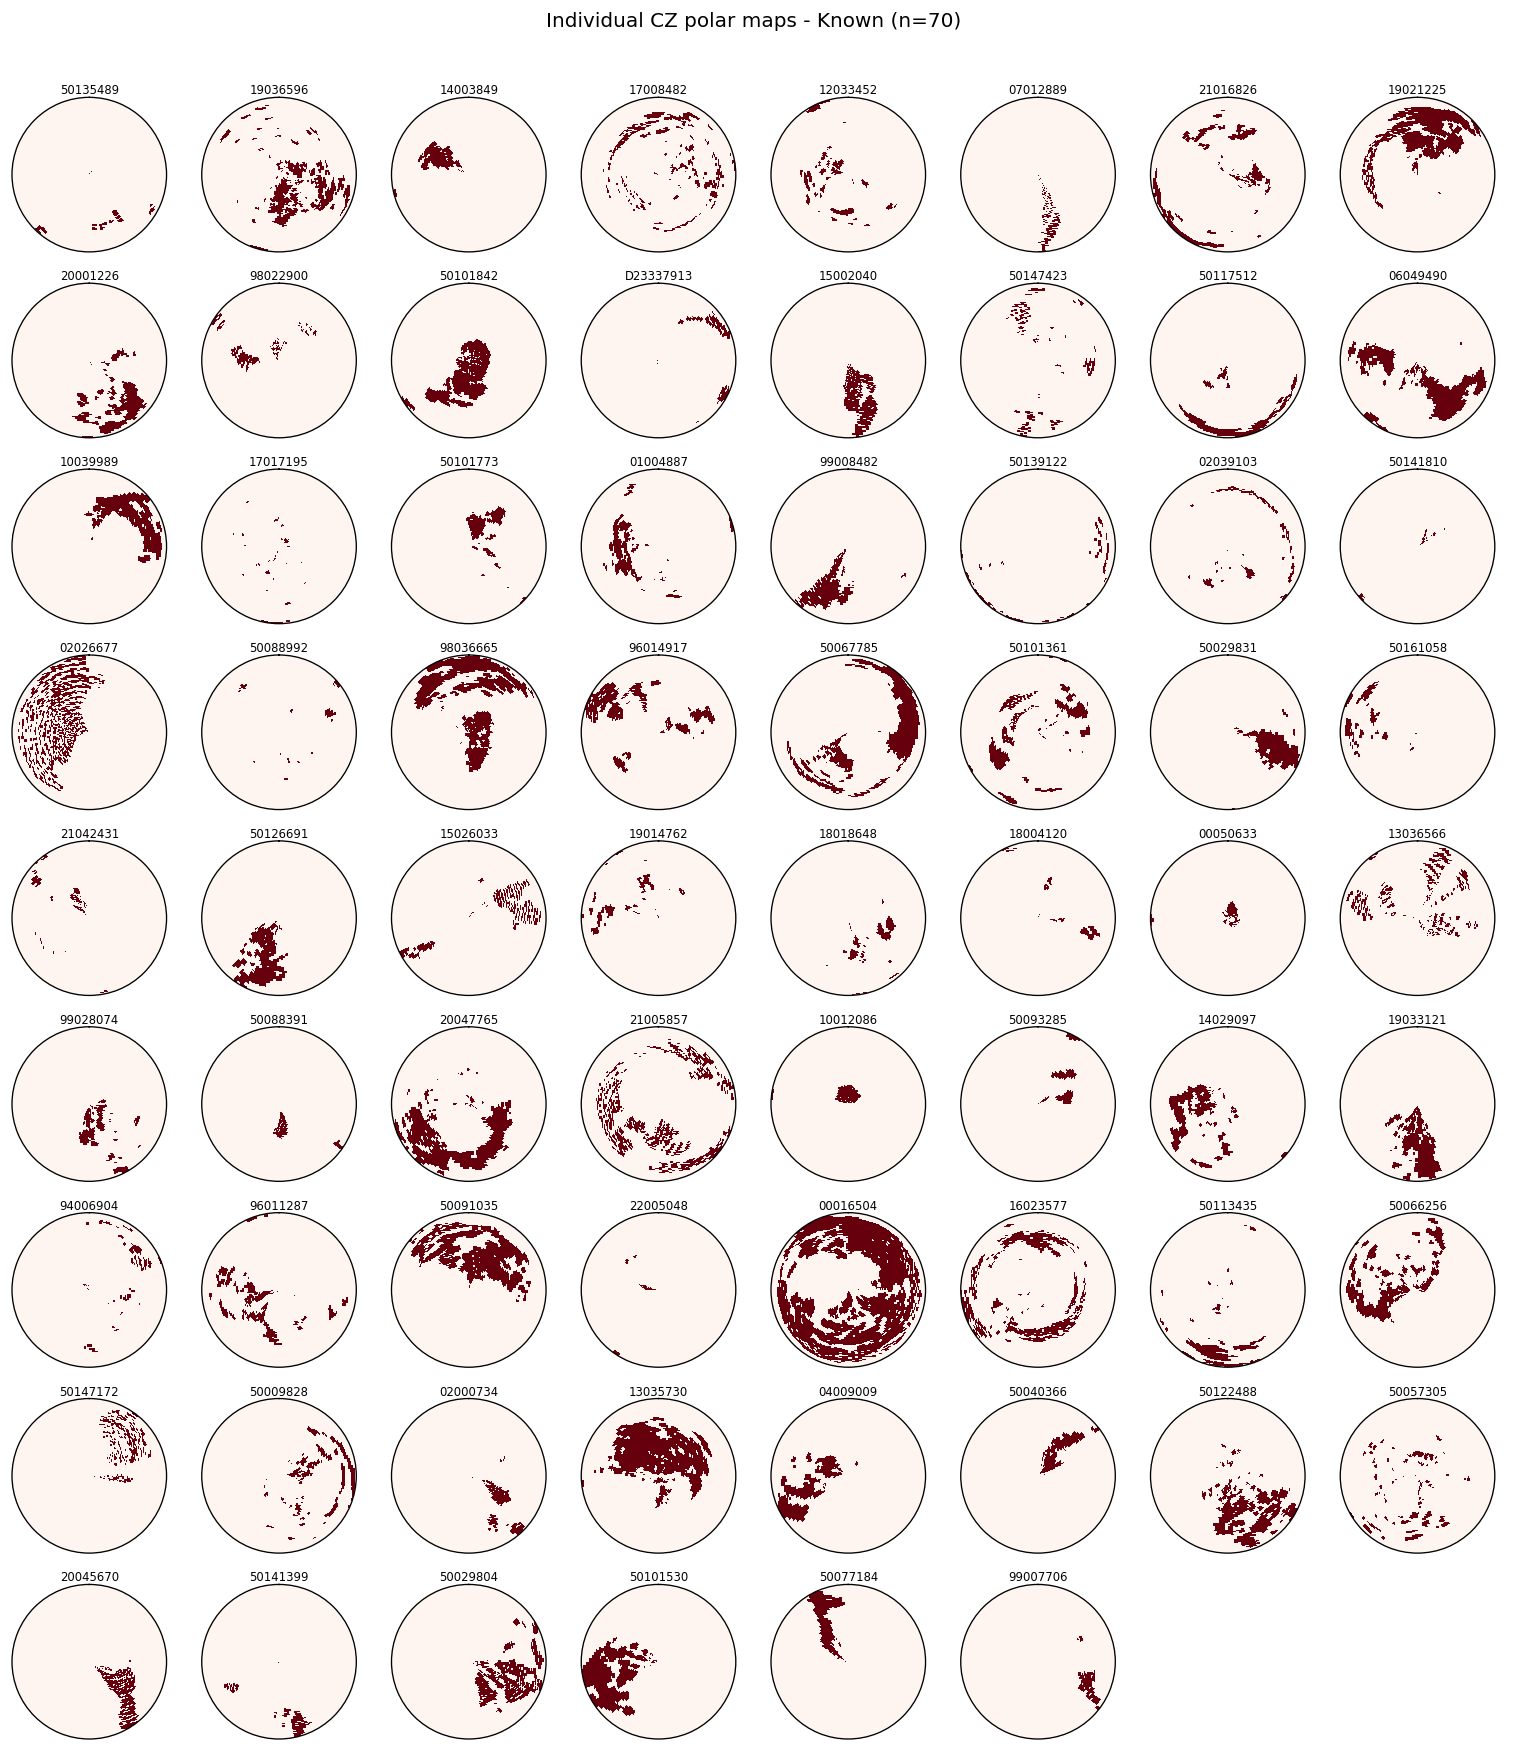

In [11]:
if not pmaps:
    print("No polar maps - check scan.")
else:
    keys  = list(pmaps.keys())
    ncols = 8
    nrows = int(np.ceil(len(keys) / ncols))
    fig   = plt.figure(figsize=(ncols*1.6, nrows*1.6))
    fig.suptitle(f"Individual CZ polar maps - Known (n={len(keys)})", fontsize=12, y=1.01)
    for idx, key in enumerate(keys):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection="polar")
        _draw_bullseye(pmaps[key], ax, title=key.split("/")[1])
    for idx in range(len(keys), nrows*ncols):
        fig.add_subplot(nrows, ncols, idx+1).axis("off")
    plt.tight_layout()
    plt.savefig(RESULTS / "polar_grid_known.png", bbox_inches="tight")
    plt.show()


### 4c - Superposition: scar density

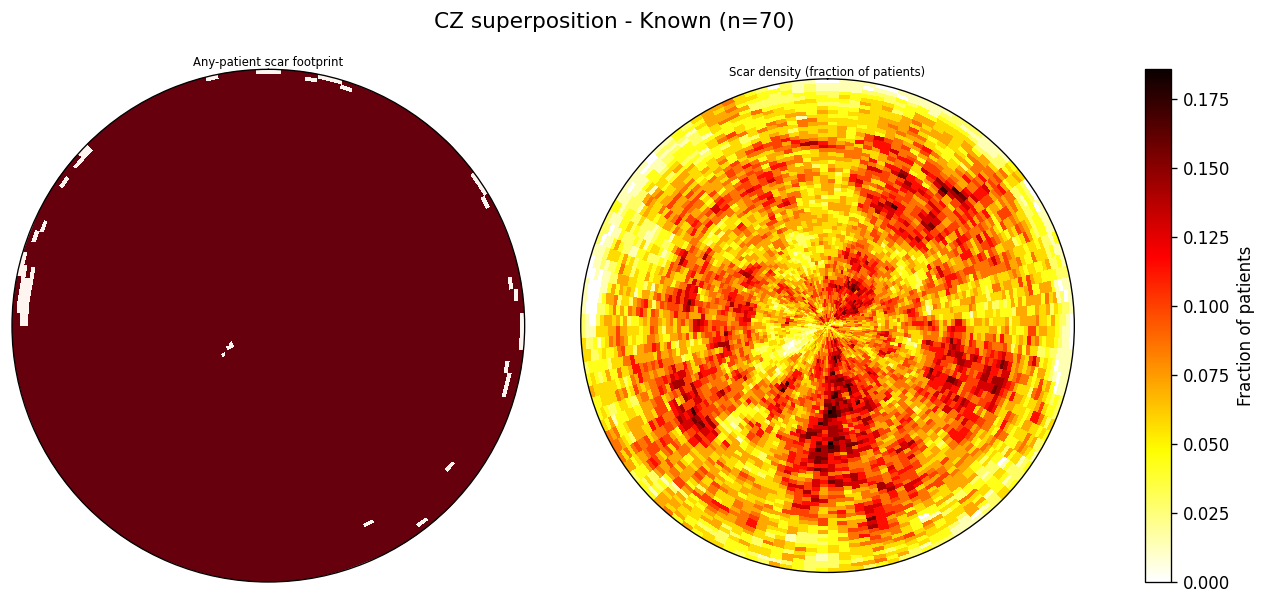

In [12]:
if not pmaps:
    print("No polar maps.")
else:
    stack   = np.stack(list(pmaps.values()))
    density = stack.mean(axis=0)
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={"projection": "polar"})
    fig.suptitle(f"CZ superposition - Known (n={len(pmaps)})", fontsize=13)
    _draw_bullseye(density > 0, ax_l, title="Any-patient scar footprint")
    _draw_bullseye(density, ax_r, title="Scar density (fraction of patients)", cmap="hot_r", vmax=density.max())
    sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, density.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax_r, pad=0.12, fraction=0.046, label="Fraction of patients")
    plt.tight_layout()
    plt.savefig(RESULTS / "polar_superposition_known.png", bbox_inches="tight")
    plt.show()


### 4d - Method comparison: dip detection vs PCA reference

Two methods are compared for finding the circumferential **theta=0** reference
(septal direction) used to align all polar maps:

| | Method A - Dip detection | Method B - PCA |
|---|---|---|
| How | Find 2 deepest radial minima in the smoothed basal ring | PC1 of the 2-D basal cross-section - concave half-axis |
| Pros | Directly targets the concavities; biologically motivated | Global shape statistic; robust to extra noise dips |
| Cons | Top-2 selection fails when artefact dips are deeper than true insertions | Axis ambiguity resolved heuristically (smaller mean radius) |

The cells below show:
1. Per-case angle difference between the two methods  
2. **Diagnostic grid** for the most disagreeing cases: basal ring with both
   reference arrows + radial profile + side-by-side bull's-eyes  
3. **Superposition comparison**: how the overall scar hot-spots shift


In [ ]:
def _ring_debug_data(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Return basal-ring 2-D data, dip peaks, and both reference directions."""
    u, w = _plane_basis(axis)
    pts  = np.array(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return None
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]] if len(peaks) >= 2 else peaks
    all_dip_pts = diff[idx[peaks]] if len(peaks) > 0 else np.zeros((0, 2))
    top2_pts    = diff[idx[top2]]  if len(top2)  > 0 else np.zeros((0, 2))
    ref_dip = _rv_reference(lv_mesh, axis, apex)
    ref_pca = _rv_reference_pca(lv_mesh, axis, apex)
    dir_dip = np.array([np.dot(ref_dip, u), np.dot(ref_dip, w)])
    dir_pca = np.array([np.dot(ref_pca, u), np.dot(ref_pca, w)])
    return dict(diff=diff, angles_sorted=angles[idx], radii_sorted=radii[idx],
                smooth_r=smooth_r, all_dip_pts=all_dip_pts, top2_pts=top2_pts,
                n_dips=len(peaks), dir_dip=dir_dip, dir_pca=dir_pca)


def _angle_diff_deg(a, b):
    d = abs(a - b) % (2 * np.pi)
    return float(np.degrees(min(d, 2*np.pi - d)))


pmaps_pca  = {}
ref_angles = {}   # key -> (angle_dip_deg, angle_pca_deg, diff_deg)
for case in tqdm(known, desc='PCA polar maps'):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps_pca[key] = polar_map(case, ref_fn=_rv_reference_pca)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        u, w = _plane_basis(axis)
        ra = _rv_reference(shell, axis, apex)
        rb = _rv_reference_pca(shell, axis, apex)
        a_dip = np.arctan2(np.dot(ra, w), np.dot(ra, u))
        a_pca = np.arctan2(np.dot(rb, w), np.dot(rb, u))
        ref_angles[key] = (np.degrees(a_dip) % 360,
                           np.degrees(a_pca) % 360,
                           _angle_diff_deg(a_dip, a_pca))
    except Exception as e:
        print(f"  skip {key}: {e}")

if ref_angles:
    diffs = np.array([v[2] for v in ref_angles.values()])
    print(f"Cases computed        : {len(ref_angles)}")
    print(f"Mean  angle diff      : {diffs.mean():.1f}°")
    print(f"Median angle diff     : {np.median(diffs):.1f}°")
    print(f"Max   angle diff      : {diffs.max():.1f}°")
    for thresh in [10, 20, 30]:
        n = (diffs > thresh).sum()
        print(f"Cases with diff > {thresh}°  : {n}")
    print()
    print('Most disagreeing cases (sorted):')
    for k, (ad, ap, diff) in sorted(ref_angles.items(), key=lambda x: -x[1][2])[:10]:
        print(f"  {k:30s}  dip={ad:6.1f}°  pca={ap:6.1f}°  Δ={diff:5.1f}°")


In [ ]:
DIAG_TOP_N = 12   # how many disagreeing cases to display

sorted_cases = sorted(ref_angles.items(), key=lambda x: -x[1][2])
diag_cases   = sorted_cases[:DIAG_TOP_N]

nrows = len(diag_cases)
if nrows == 0:
    print('No cases to show.')
else:
    fig = plt.figure(figsize=(16, nrows * 3.2))
    fig.suptitle(
        f"Top-{nrows} most disagreeing cases  |  "
        "Col 1: basal ring  Col 2: radial profile  "
        "Col 3: bull's-eye A (dip)  Col 4: bull's-eye B (PCA)",
        fontsize=10, y=1.01)
    gs = gridspec.GridSpec(nrows, 4, figure=fig, hspace=0.55, wspace=0.35)

    for row, (key, (ad, ap, diff_deg)) in enumerate(diag_cases):
        year, pid = key.split('/')
        case  = next(c for c in known if c.patient_id == pid and str(c.year) == year)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        data  = _ring_debug_data(shell, axis, apex)

        ax_ring    = fig.add_subplot(gs[row, 0])
        ax_profile = fig.add_subplot(gs[row, 1])
        ax_dip_map = fig.add_subplot(gs[row, 2], projection='polar')
        ax_pca_map = fig.add_subplot(gs[row, 3], projection='polar')

        if data is None:
            for ax in [ax_ring, ax_profile, ax_dip_map, ax_pca_map]:
                ax.axis('off')
            ax_ring.set_title(f"{key}\nno ring data", fontsize=8)
            continue

        # Ring scatter
        d2 = data['diff']
        r2 = np.linalg.norm(d2, axis=1)
        ax_ring.scatter(d2[:, 0], d2[:, 1], c=r2, cmap='viridis_r', s=4, alpha=0.5)
        if len(data['all_dip_pts']) > 0:
            ax_ring.scatter(data['all_dip_pts'][:, 0], data['all_dip_pts'][:, 1],
                            marker='x', c='gray', s=50, linewidths=1.2, zorder=3)
        if len(data['top2_pts']) > 0:
            ax_ring.scatter(data['top2_pts'][:, 0], data['top2_pts'][:, 1],
                            marker='o', c='red', s=70, zorder=4)
        scale = r2.max() * 1.3
        ax_ring.annotate('', xy=data['dir_dip'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
        ax_ring.annotate('', xy=data['dir_pca'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.0))
        ax_ring.set_aspect('equal')
        ax_ring.set_title(f"{key}\n{data['n_dips']} dips | Δ={diff_deg:.0f}°", fontsize=8)
        handles = [
            plt.Line2D([0],[0], color='red',       lw=2, label='A - dip ref'),
            plt.Line2D([0],[0], color='dodgerblue', lw=2, label='B - PCA ref'),
            plt.Line2D([0],[0], marker='x', color='gray', ls='None',
                       markersize=6, label=f"all peaks ({data['n_dips']})"),
            plt.Line2D([0],[0], marker='o', color='red', ls='None',
                       markersize=6, label='top-2 selected'),
        ]
        ax_ring.legend(handles=handles, fontsize=5, loc='upper right')

        # Radial profile
        ang_deg = np.degrees(data['angles_sorted'])
        ax_profile.plot(ang_deg, data['radii_sorted'], alpha=0.35, color='gray', lw=1, label='raw')
        ax_profile.plot(ang_deg, data['smooth_r'], color='black', lw=1.5, label='smooth')
        for pk_pt in data['all_dip_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='gray', alpha=0.5, lw=1, ls='--')
        for pk_pt in data['top2_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='red', lw=1.5, ls='--')
        ax_profile.axvline(ad if ad <= 180 else ad - 360, color='red',
                           lw=1.5, ls='-', label=f'A θ={ad:.0f}°')
        ax_profile.axvline(ap if ap <= 180 else ap - 360, color='dodgerblue',
                           lw=1.5, ls='-', label=f'B θ={ap:.0f}°')
        ax_profile.set_xlabel('angle (°)', fontsize=7)
        ax_profile.set_ylabel('radius', fontsize=7)
        ax_profile.set_title('Radial profile', fontsize=8)
        ax_profile.legend(fontsize=5)
        ax_profile.tick_params(labelsize=6)

        # Bull's-eyes
        if key in pmaps:
            _draw_bullseye(pmaps[key],     ax_dip_map, title='A - dip')
        else:
            ax_dip_map.axis('off')
        if key in pmaps_pca:
            _draw_bullseye(pmaps_pca[key], ax_pca_map, title='B - PCA')
        else:
            ax_pca_map.axis('off')

    plt.savefig(RESULTS / 'method_comparison_diagnostic.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_diagnostic.png')


In [ ]:
common = sorted(set(pmaps) & set(pmaps_pca))
if not common:
    print('No common cases.')
else:
    stack_dip = np.stack([pmaps[k]     for k in common])
    stack_pca = np.stack([pmaps_pca[k] for k in common])
    dens_dip  = stack_dip.mean(axis=0)
    dens_pca  = stack_pca.mean(axis=0)
    vmax      = max(dens_dip.max(), dens_pca.max())

    fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                             subplot_kw={'projection': 'polar'})
    fig.suptitle(f"Superposition comparison  (n={len(common)} cases)", fontsize=12)

    _draw_bullseye(dens_dip > 0, axes[0], title="A - dip  |  any-patient footprint")
    _draw_bullseye(dens_dip,     axes[1], title="A - dip  |  scar density",
                   cmap='hot_r', vmax=vmax)
    _draw_bullseye(dens_pca > 0, axes[2], title="B - PCA  |  any-patient footprint")
    _draw_bullseye(dens_pca,     axes[3], title="B - PCA  |  scar density",
                   cmap='hot_r', vmax=vmax)

    sm = plt.cm.ScalarMappable(cmap='hot_r', norm=plt.Normalize(0, vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    fig.colorbar(sm, ax=axes[3], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    plt.tight_layout()
    plt.savefig(RESULTS / 'method_comparison_superposition.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_superposition.png')


## 5 - ISOMAP shape analysis

| Situation | Action |
|---|---|
| 1 fragment | ISOMAP on all vertices |
| N fragments | ISOMAP on each fragment separately + fragmentation features |

Why per-fragment: geodesic distances between disconnected islands are infinite.
Running ISOMAP independently per fragment avoids a corrupted distance matrix.

Fragments with fewer than MIN_VERTS_ISOMAP vertices are counted but not embedded.

Future note: tiny sub-scars could be filtered by area or vertex count. For now all are kept.

In [13]:
@dataclass
class CZAnalysis:
    key:                  str
    n_fragments:          int
    vertex_counts:        list
    largest_fraction:     float
    centroids:            np.ndarray
    centroid_dist_matrix: np.ndarray
    embeddings:           list

    @property
    def is_compact(self):
        return self.n_fragments == 1


def _run_isomap(pts, k=ISOMAP_K, n_pts=ISOMAP_PTS):
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def analyze_cz(case):
    key     = f"{case.year}/{case.patient_id}"
    cz      = pv.read(str(case.tissue_surfaces["core"]))
    labeled = cz.connectivity(largest=False)
    n_frags = int(labeled["RegionId"].max()) + 1
    reg_ids = np.array(labeled["RegionId"])
    all_pts = np.array(labeled.points)
    frag_indices = sorted(range(n_frags),
                          key=lambda i: np.sum(reg_ids == i), reverse=True)
    vertex_counts, centroids, embeddings = [], [], []
    for fid in frag_indices:
        mask = reg_ids == fid
        pts  = all_pts[mask]
        vertex_counts.append(len(pts))
        centroids.append(pts.mean(axis=0))
        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_run_isomap(pts))
            except Exception as e:
                print(f"    ISOMAP failed {key}: {e}")
                embeddings.append(None)
        else:
            embeddings.append(None)
    centroids = np.array(centroids)
    dist_mat  = cdist(centroids, centroids) if len(centroids) > 1 else np.zeros((1, 1))
    return CZAnalysis(
        key=key, n_fragments=n_frags,
        vertex_counts=vertex_counts,
        largest_fraction=vertex_counts[0] / max(sum(vertex_counts), 1),
        centroids=centroids, centroid_dist_matrix=dist_mat, embeddings=embeddings,
    )

print("CZAnalysis helpers ready.")


CZAnalysis helpers ready.


### 5a - Run analysis on Known set

In [14]:
analyses = {}
for case in tqdm(known, desc="ISOMAP analysis"):
    key = f"{case.year}/{case.patient_id}"
    try:
        analyses[key] = analyze_cz(case)
    except Exception as e:
        print(f"  skip {key}: {e}")

compact    = [a for a in analyses.values() if a.is_compact]
fragmented = [a for a in analyses.values() if not a.is_compact]
print(f"Analysed        : {len(analyses)}")
print(f"Compact (1 frag): {len(compact)}")
print(f"Fragmented (>1) : {len(fragmented)}")


ISOMAP analysis:   6%|â–Œ         | 4/70 [00:00<00:01, 36.71it/s]

  skip 2024/50135489: boolean index did not match indexed array along axis 0; size of axis is 206 but size of corresponding boolean axis is 384
  skip 2022/19036596: boolean index did not match indexed array along axis 0; size of axis is 10014 but size of corresponding boolean axis is 19008
  skip 2021/14003849: boolean index did not match indexed array along axis 0; size of axis is 1473 but size of corresponding boolean axis is 2892
  skip 2023/17008482: boolean index did not match indexed array along axis 0; size of axis is 2226 but size of corresponding boolean axis is 3924
  skip 2023/12033452: boolean index did not match indexed array along axis 0; size of axis is 2134 but size of corresponding boolean axis is 3976
  skip 2023/07012889: boolean index did not match indexed array along axis 0; size of axis is 204 but size of corresponding boolean axis is 404
  skip 2022/21016826: boolean index did not match indexed array along axis 0; size of axis is 3426 but size of corresponding b

ISOMAP analysis:  23%|â–ˆâ–ˆâ–Ž       | 16/70 [00:00<00:01, 49.69it/s]

  skip 2021/98022900: boolean index did not match indexed array along axis 0; size of axis is 712 but size of corresponding boolean axis is 1384
  skip 2024/50101842: boolean index did not match indexed array along axis 0; size of axis is 7860 but size of corresponding boolean axis is 15644
  skip 2023/D23337913: boolean index did not match indexed array along axis 0; size of axis is 252 but size of corresponding boolean axis is 472
  skip 2021/15002040: boolean index did not match indexed array along axis 0; size of axis is 1656 but size of corresponding boolean axis is 3316
  skip 2024/50147423: boolean index did not match indexed array along axis 0; size of axis is 532 but size of corresponding boolean axis is 932
  skip 2024/50117512: boolean index did not match indexed array along axis 0; size of axis is 2672 but size of corresponding boolean axis is 5252
  skip 2023/06049490: boolean index did not match indexed array along axis 0; size of axis is 5504 but size of corresponding bo

ISOMAP analysis:  40%|â–ˆâ–ˆâ–ˆâ–ˆ      | 28/70 [00:00<00:00, 52.58it/s]

...

  skip 2022/21005857: boolean index did not match indexed array along axis 0; size of axis is 1622 but size of corresponding boolean axis is 3180
  skip 2021/10012086: boolean index did not match indexed array along axis 0; size of axis is 2404 but size of corresponding boolean axis is 4804
  skip 2024/50093285: boolean index did not match indexed array along axis 0; size of axis is 896 but size of corresponding boolean axis is 1776
  skip 2023/14029097: boolean index did not match indexed array along axis 0; size of axis is 4166 but size of corresponding boolean axis is 8052
  skip 2021/19033121: boolean index did not match indexed array along axis 0; size of axis is 4006 but size of corresponding boolean axis is 7864
  skip 2023/94006904: boolean index did not match indexed array along axis 0; size of axis is 390 but size of corresponding boolean axis is 648
  skip 2023/96011287: boolean index did not match indexed array along axis 0; size of axis is 3272 but size of corresponding bo

ISOMAP analysis:  83%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–Ž | 58/70 [00:01<00:00, 44.35it/s]

  skip 2023/00016504: boolean index did not match indexed array along axis 0; size of axis is 12818 but size of corresponding boolean axis is 25484
  skip 2022/16023577: boolean index did not match indexed array along axis 0; size of axis is 2464 but size of corresponding boolean axis is 4636
  skip 2024/50113435: boolean index did not match indexed array along axis 0; size of axis is 1086 but size of corresponding boolean axis is 2004
  skip 2023/50066256: boolean index did not match indexed array along axis 0; size of axis is 6948 but size of corresponding boolean axis is 13572
  skip 2025/50147172: boolean index did not match indexed array along axis 0; size of axis is 380 but size of corresponding boolean axis is 748
  skip 2023/50009828: boolean index did not match indexed array along axis 0; size of axis is 2964 but size of corresponding boolean axis is 5500
  skip 2024/02000734: boolean index did not match indexed array along axis 0; size of axis is 734 but size of corresponding

ISOMAP analysis: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 70/70 [00:01<00:00, 47.64it/s]

  skip 2023/50040366: boolean index did not match indexed array along axis 0; size of axis is 4806 but size of corresponding boolean axis is 9512
  skip 2024/50122488: boolean index did not match indexed array along axis 0; size of axis is 3444 but size of corresponding boolean axis is 6616
  skip 2023/50057305: boolean index did not match indexed array along axis 0; size of axis is 1992 but size of corresponding boolean axis is 3572
  skip 2021/20045670: boolean index did not match indexed array along axis 0; size of axis is 716 but size of corresponding boolean axis is 1416
  skip 2024/50141399: boolean index did not match indexed array along axis 0; size of axis is 306 but size of corresponding boolean axis is 576
  skip 2022/50029804: boolean index did not match indexed array along axis 0; size of axis is 2406 but size of corresponding boolean axis is 4740
  skip 2024/50101530: boolean index did not match indexed array along axis 0; size of axis is 4246 but size of corresponding bo

### 5b - ISOMAP embedding grid

- Gray border = compact (1 fragment)
- Orange border = fragmented (each fragment a different colour)
- x marker = fragment too small to embed

In [15]:
FRAG_CMAP = plt.get_cmap("tab10")

def _plot_isomap_cell(ax, analysis):
    for fi, (emb, count) in enumerate(zip(analysis.embeddings, analysis.vertex_counts)):
        color = "crimson" if analysis.is_compact else FRAG_CMAP(fi % 10)
        if emb is not None and len(emb) > 0:
            ax.scatter(emb[:, 0], emb[:, 1], s=1, c=[color], alpha=0.6, linewidths=0)
        else:
            ax.scatter([0], [0], marker="x", s=20, c=[color], linewidths=1)
    n   = analysis.n_fragments
    pid = analysis.key.split("/")[1]
    ax.set_title(f"{pid} ({n}f)" if n > 1 else pid, fontsize=6, pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    try:
        ax.set_aspect("equal", adjustable="datalim")
    except Exception:
        pass
    bc = "orange" if not analysis.is_compact else "#888888"
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color(bc)


if not analyses:
    print("No analyses available - check scan.")
else:
    ikeys = list(analyses.keys())
    ncols = 8
    nrows = max(1, int(np.ceil(len(ikeys) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.8), squeeze=False)
    fig.suptitle(
        f"ISOMAP shape embeddings - Known CZ (n={len(ikeys)})  gray=compact  orange=fragmented",
        fontsize=11, y=1.01
    )
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")
    for ax, key in zip(axes_flat, ikeys):
        ax.axis("on")
        try:
            _plot_isomap_cell(ax, analyses[key])
        except Exception as e:
            ax.set_title(key.split("/")[1], fontsize=6)
            print(f"  plot failed {key}: {e}")
    plt.tight_layout()
    plt.savefig(RESULTS / "isomap_grid_known.png", bbox_inches="tight")
    plt.show()


No analyses available - check scan.


### 5c - Fragmentation summary

In [16]:
if not analyses:
    print("No analyses.")
else:
    n_frags_all      = [a.n_fragments      for a in analyses.values()]
    largest_frac_all = [a.largest_fraction for a in analyses.values()]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("CZ fragmentation - Known set", fontsize=13)
    ax = axes[0]
    ax.hist(n_frags_all, bins=range(1, max(n_frags_all)+2), align="left",
            color="steelblue", edgecolor="white", rwidth=0.8)
    ax.axvline(1.5, color="orange", lw=1.5, ls="--", label="compact/fragmented")
    ax.set_xlabel("Number of fragments"); ax.set_ylabel("Patients")
    ax.set_title("Fragment count"); ax.legend(fontsize=8)
    ax = axes[1]
    ax.hist(largest_frac_all, bins=20, color="crimson", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Largest fragment / total vertices"); ax.set_ylabel("Patients")
    ax.set_title("Compactness (1.0 = single solid scar)")
    ax = axes[2]
    top10  = sorted(analyses.values(), key=lambda a: a.n_fragments, reverse=True)[:10]
    labels = [a.key.split("/")[1] for a in top10]
    counts = [a.n_fragments for a in top10]
    bars   = ax.barh(labels[::-1], counts[::-1], color="darkorange", edgecolor="white")
    ax.set_xlabel("Number of fragments"); ax.set_title("Top-10 most fragmented")
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                str(val), va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS / "fragmentation_summary.png", bbox_inches="tight")
    plt.show()
    print(f"Median fragments: {int(np.median(n_frags_all))}")
    print(f"Max fragments   : {max(n_frags_all)}")
    print(f"Compact patients: {sum(1 for n in n_frags_all if n == 1)}")


No analyses.


---
## Outputs

| File | Content |
|---|---|
| results/split.json | Frozen Known/Held-out lists |
| results/3d_overlay_known.png | Aligned CZ overlay |
| results/3d_grid_known.png | Per-patient 3-D thumbnails |
| results/polar_grid_known.png | Individual bull's-eye maps |
| results/polar_superposition_known.png | Population scar density |
| results/isomap_grid_known.png | Per-scar ISOMAP embeddings |
| results/fragmentation_summary.png | Fragment distribution |